In [ ]:
    ####### Installing SHAP by typing:
# conda install conda-forge::shap in Anaconda prompt  
# pip install shap in command prompt ########

In [2]:
### Importing the necessary libraries #########
# For Tabular data
import pandas as pd
# For generic Maths
import numpy as np
from numpy import absolute
# For scaling purposes
from sklearn.preprocessing import StandardScaler
# For Variance Inlfation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
# To split the dataset
from sklearn.model_selection import train_test_split
# Metrics and GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
# Modeling
from sklearn.ensemble import GradientBoostingRegressor
# Shap
import shap
# To ignore warning messages
import warnings
warnings.filterwarnings("ignore")
# For reproducibility purposes
seed = 7

In [3]:
# Reading the dataset
lake = pd.read_csv('E:/XAI/LakeXAI.csv')
#lake = pd.read_csv('C:/Users/Public/XAI/LakeXAI.csv')

In [4]:
lake.head()

,T,R_E,R_AT,R_P,G_E,G_AT,G_P,R_LL,G_LL
0,1/1/2013,0.635469,26.684,0.06,12.7,22.55,0.0,281.86,280.39
1,2/1/2013,0.409592,28.214,0.00,13.1,24.40,0.0,281.60,280.19
2,3/1/2013,0.501878,30.321,0.45,11.5,31.85,0.0,281.34,279.96
3,4/1/2013,1.896789,30.941,2.53,11.2,33.15,0.0,281.09,279.65
4,5/1/2013,11.177511,30.767,8.78,9.6,32.60,0.0,281.00,279.40


In [5]:
# Data description
lake.describe()

,R_E,R_AT,R_P,G_E,G_AT,G_P,R_LL,G_LL
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,20.992243,28.368933,41.858056,9.208333,28.912500,24.374074,281.426111,279.761852
std,24.699415,2.807062,64.048078,4.786432,3.714131,47.042366,0.453857,0.553939
min,0.244746,21.720941,0.000000,0.200000,20.750000,0.000000,280.510000,278.300000
25%,0.789197,26.863723,0.052500,4.975000,25.375000,0.000000,281.052500,279.360000
50%,7.116494,28.687451,4.310000,9.700000,30.275000,0.000000,281.410000,279.745000
75%,44.921698,30.633814,72.317501,13.625000,31.675000,27.075000,281.822500,280.237500
max,75.910866,33.223901,229.970001,16.800000,33.800000,209.700000,282.400000,280.830000


In [6]:
## Preparing the input and output variables

In [7]:
# The output variables or targets

In [8]:
# The remote sensing ouput variable
y_R = lake['R_LL']

In [9]:
y_R.shape

(108,)

In [10]:
print(y_R[:5])

0    281.86
1    281.60
2    281.34
3    281.09
4    281.00
Name: R_LL, dtype: float64


In [11]:
# The ground-truth output variable
y_G = lake['G_LL']

In [12]:
y_G.shape

(108,)

In [13]:
print(y_G[:5])

0    280.39
1    280.19
2    279.96
3    279.65
4    279.40
Name: G_LL, dtype: float64


In [14]:
# The features or input variables

In [15]:
# The remote sensing features
X_R = lake.drop(['T','R_LL','G_LL','G_E', 'G_AT','G_P'], axis = 1)


In [16]:
X_R.shape

(108, 3)

In [17]:
print(X_R[:5])

         R_E    R_AT   R_P
0   0.635469  26.684  0.06
1   0.409592  28.214  0.00
2   0.501878  30.321  0.45
3   1.896789  30.941  2.53
4  11.177511  30.767  8.78


In [18]:
# The ground-truth features

X_G = lake.drop(['T','R_LL','G_LL','R_E', 'R_AT','R_P'], axis = 1)

In [19]:
X_G.shape

(108, 3)

In [20]:
print(X_G[:5])

    G_E   G_AT  G_P
0  12.7  22.55  0.0
1  13.1  24.40  0.0
2  11.5  31.85  0.0
3  11.2  33.15  0.0
4   9.6  32.60  0.0


In [21]:
# Standardizing / Scaling the features

In [22]:
# Scaling the RS input features
X_R_scaled = pd.DataFrame(StandardScaler().fit_transform(X_R),
columns= X_R.columns, index  = X_R.index)

In [23]:
# Scaling the GT features
X_G_scaled = pd.DataFrame(StandardScaler().fit_transform(X_G),
columns= X_G.columns, index  = X_G.index)

In [24]:
# VIF

In [25]:
### X_R VIF
vif = pd.DataFrame()
vif['vif'] = [variance_inflation_factor(X_R_scaled,i) for i in range(X_R_scaled.shape[1])]
vif['Features'] = X_R.columns
vif.round(2)

,vif,Features
0,6.67,R_E
1,1.11,R_AT
2,6.43,R_P


In [26]:
### X_G VIF
vif = pd.DataFrame()
vif['vif'] = [variance_inflation_factor(X_G_scaled,i) for i in range(X_G_scaled.shape[1])]
vif['Features'] = X_G.columns
vif.round(2)

,vif,Features
0,2.38,G_E
1,1.27,G_AT
2,2.02,G_P


In [27]:
# Splitting the data into training and testing datasets

In [28]:
# Splitting the RS Data
X_R_train, X_R_test, y_R_train, y_R_test = train_test_split(X_R_scaled, y_R, test_size = 0.30, random_state = 30, shuffle = True)

In [29]:
print(X_R_train.shape, X_R_test.shape)

(75, 3) (33, 3)


In [30]:
# Splitting the GT Data

X_G_train, X_G_test, y_G_train, y_G_test = train_test_split(X_G_scaled, y_G, test_size = 0.30, random_state = 30, shuffle = True)

In [31]:
print(X_G_train.shape, X_G_test.shape)

(75, 3) (33, 3)


In [ ]:
    ##################### GRADIENT BOOSTING REGRESSION ###################

In [ ]:
############ MODEL 3: RS Features (X_R) and GT Target (LL_G)###############

In [245]:
model = GradientBoostingRegressor()
gbr_param_grid = { 'learning_rate' : [0.01, 0.02, 0.03, 0.04, 0.05],
                  'n_estimators' : [100, 500, 1000, 1500],
                  'subsample' : [0.1, 0.3, 0.5, 0.7, 0.9, 1],
                 'max_depth' : [4, 6, 8, 10, 12],
                    }
gbr_cv = KFold(n_splits = 10, random_state = 1, shuffle = True)
gbr3 = GridSearchCV(model, gbr_param_grid, cv = gbr_cv, scoring = 'neg_mean_squared_error', n_jobs = -1)
gbr3.fit(X_R, y_G)

GridSearchCV(cv=KFold(n_splits=10, random_state=1, shuffle=True),
             estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05],
                         'max_depth': [4, 6, 8, 10, 12],
                         'n_estimators': [100, 500, 1000, 1500],
                         'subsample': [0.1, 0.3, 0.5, 0.7, 0.9, 1]},
             scoring='neg_mean_squared_error')

In [246]:
# Printing the best parameters and the best score
print('The best parameters are:', gbr3.best_params_)
print('The best score is:', gbr3.best_score_)

The best parameters are: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000, 'subsample': 0.1}
The best score is: -0.12583137036701456


In [ ]:
# learning_rate = 0.02, max_depth = 12, n_estimators = 500, subsample = 0.1

In [32]:
########### Fitting the model on the training dataset using the best parameters
# Instantiation
model = GradientBoostingRegressor(learning_rate = 0.01, max_depth = 4, n_estimators = 1000, subsample = 0.1)

In [33]:
# Fitting the model
gbr3 = model.fit(X_R_train, y_G_train)

In [71]:
# Evaluation of the performance of the training model:
gbr_y_predtr = gbr3.predict(X_R_train)
print('The training MAE is:', mean_absolute_error(y_G_train, gbr_y_predtr))
print('The training MSE is:', mean_squared_error(y_G_train, gbr_y_predtr))
print('The training R2 Score is:', r2_score(y_G_train, gbr_y_predtr))

The training MAE is: 0.19148726842929592
The training MSE is: 0.06280958996328376
The training R2 Score is: 0.7845234664051448


In [72]:
# Evaluation of the performance of the testing model:
gbr_y_predts = gbr3.predict(X_R_test)
print('The testing MAE is:', mean_absolute_error(y_G_test, gbr_y_predts))
print('The testing MSE is:', mean_squared_error(y_G_test, gbr_y_predts))
print('The testing R2 Score is:', r2_score(y_G_test, gbr_y_predts))

The testing MAE is: 0.2750937913256752
The testing MSE is: 0.1123096868404203
The testing R2 Score is: 0.6479395156419334


In [73]:
##################### k-fold Cross-validation ##############################

In [74]:
############# On the training dataset
 
score_gbr3tr = cross_val_score(gbr3, X_R_train, y_G_train, scoring = 'neg_mean_squared_error', cv = 10)

In [75]:
# The mean training score
print('The mean training CV score is:', absolute(np.mean(score_gbr3tr)))

The mean training CV score is: 0.16701771054968556


In [76]:
############# On the testing dataset 
score_gbr3ts = cross_val_score(gbr3, X_R_test, y_G_test, scoring = 'neg_mean_squared_error', cv = 10)

In [77]:
# The mean testing score
print('The mean testing CV score is:', absolute(np.mean(score_gbr3ts)))

The mean testing CV score is: 0.15117817509740625


In [34]:
                        ##################### SHAP ###################
shap.initjs()

In [36]:
###### Initializing the explainer on the training dataset
explainer = shap.KernelExplainer(gbr3.predict, X_R_train)

In [37]:
# Explanation of the prediction using the training datasset
shap_valuestr = explainer.shap_values(X_R_train)

  0%|          | 0/75 [00:00<?, ?it/s]

In [38]:
shap_valuestr

array([[ 0.2570538 ,  0.11469071, -0.69797732],
       [ 0.0031302 , -0.29889921, -0.03358882],
       [ 0.00133364, -0.26584841, -0.07892959],
       [ 0.24247911,  0.04551202, -0.69883707],
       [ 0.21132352,  0.16686916, -0.44653832],
       [-0.03205634, -0.26799409,  0.21642279],
       [-0.23624385,  0.12223618,  0.38023302],
       [ 0.0689857 ,  0.02546329, -0.58150855],
       [-0.08970373,  0.17834457,  0.52735981],
       [ 0.14908456, -0.23518143, -0.44030782],
       [-0.02877215,  0.12308846,  0.50285526],
       [ 0.22212995,  0.11928527, -0.41600855],
       [ 0.11450355, -0.01713126, -0.39126047],
       [ 0.14933953,  0.10143886, -0.63719398],
       [ 0.19421108,  0.06341941, -0.7054218 ],
       [ 0.03043273,  0.18428829,  0.54062625],
       [-0.28631604,  0.07583772,  0.30358777],
       [-0.04557978, -0.3313239 ,  0.07222213],
       [-0.26267534,  0.08375807,  0.3245473 ],
       [-0.19575831,  0.17755849,  0.5417704 ],
       [ 0.10969582,  0.0713824 , -0.385

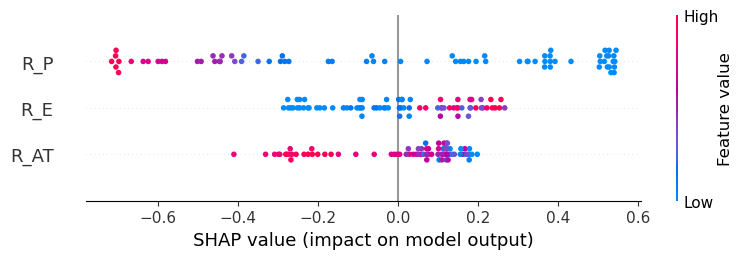

In [39]:
##### Shap summary plot
shap.summary_plot(shap_valuestr, X_R_train, feature_names = X_R_train.columns)

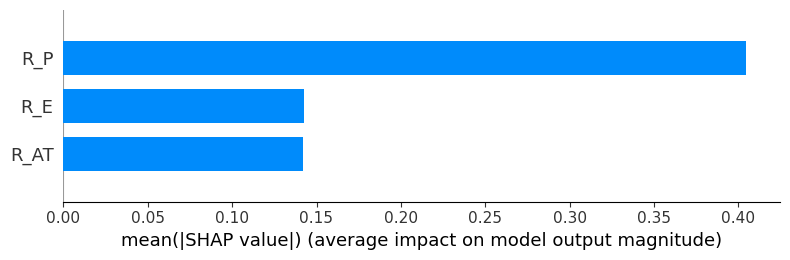

In [40]:
###### Shap feature importance plot
shap.summary_plot(shap_valuestr, X_R_train, feature_names = X_R_train.columns, plot_type = 'bar')

  0%|          | 0/75 [00:00<?, ?it/s]

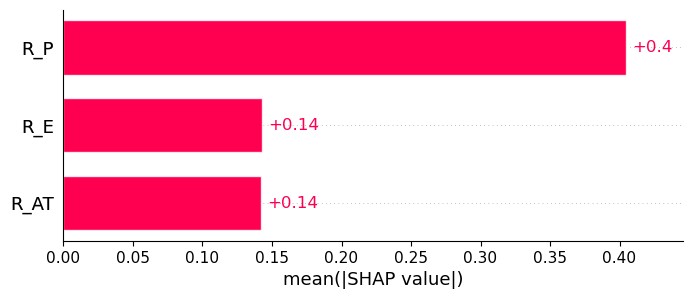

In [41]:
## Global bar plot
shap_valuestr = explainer(X_R_train)
shap.plots.bar(shap_valuestr)

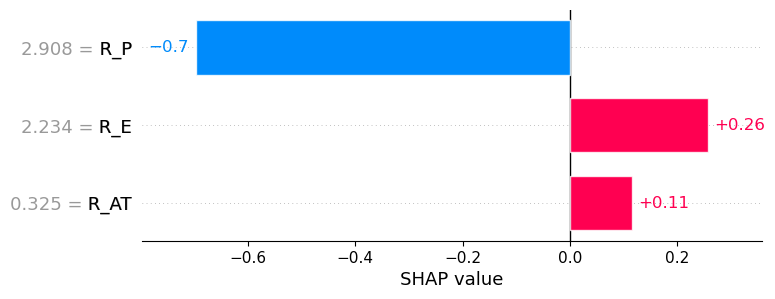

In [42]:
## Local bar plot
shap.plots.bar(shap_valuestr[0])

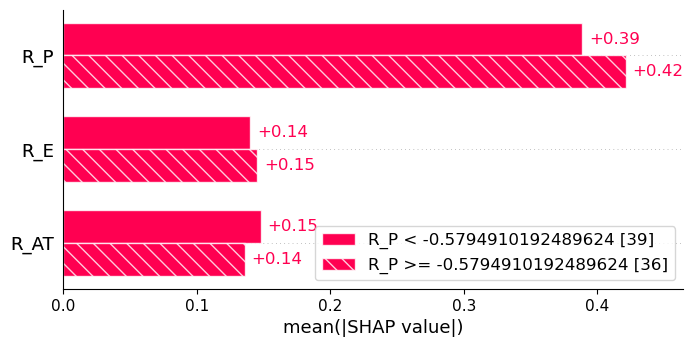

In [43]:
# Auto-cohort plot
shap.plots.bar(shap_valuestr.cohorts(2).abs.mean(0))

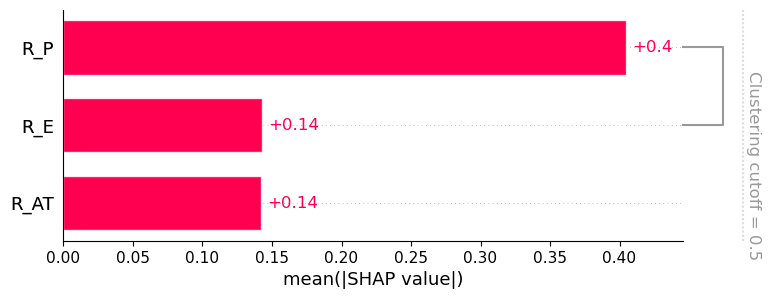

In [44]:
# Feature clustering
clustering = shap.utils.hclust(X_R_train, y_G_train)
shap.plots.bar(shap_valuestr, clustering = clustering)

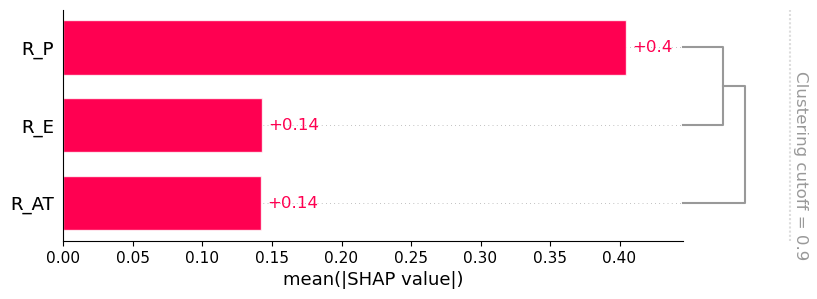

In [45]:
# Feature clustering
clustering = shap.utils.hclust(X_R_train, y_G_train)
shap.plots.bar(shap_valuestr, clustering = clustering, clustering_cutoff = 0.9)

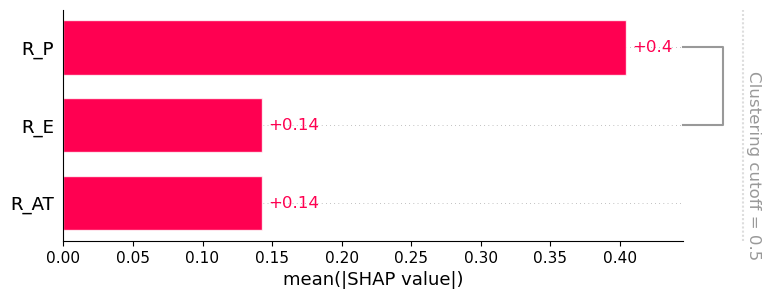

In [46]:
# shap.maskers.TabularPartitions
def f(x):
    return gbr3.predict(x)
# Defining a partition nasker that uses the ckustering
masker = shap.maskers.Partition(X_R_train, clustering = clustering)

# Model explanation

explainerts = shap.Explainer(f, masker)

# shap_values

shap_values_partition = explainerts(X_R_train)

# Generating the plot

shap.plots.bar(shap_values_partition)


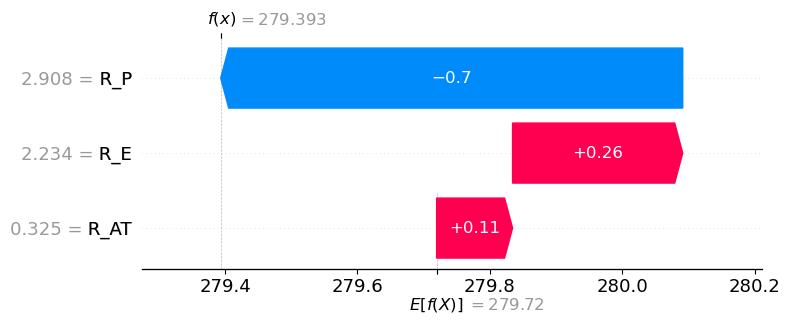

In [47]:
# Waterfall plot
shap.plots.waterfall(shap_valuestr[0])

In [48]:
# Froce plot
shap.plots.force(shap_valuestr[0])

In [49]:
################## Explanation of the prediction for the testing datasset#################
shap_valuests = explainer.shap_values(X_R_test)

  0%|          | 0/33 [00:00<?, ?it/s]

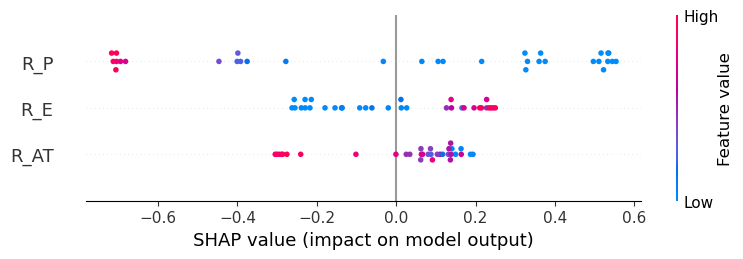

In [50]:
# SHAP Summary Plot
# Combination of feature importance and feature effect
shap.summary_plot(shap_valuests, X_R_test, feature_names = X_R_test.columns)

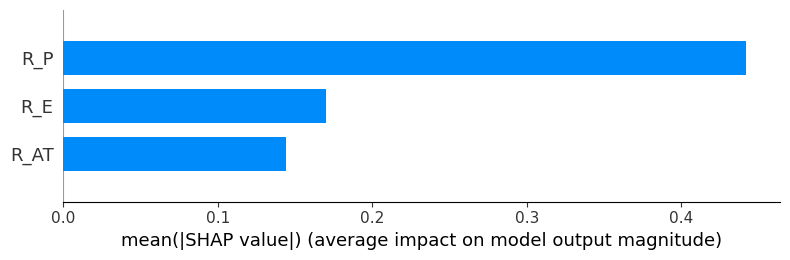

In [51]:
# SHAP Feature Importance Plot
# Features with large absolute Shapley values are important
shap.summary_plot(shap_valuests, X_R_test, feature_names = X_R_test.columns, plot_type = 'bar')

  0%|          | 0/33 [00:00<?, ?it/s]

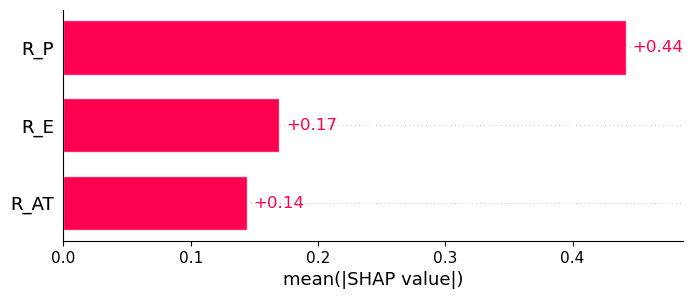

In [52]:
# Global Bar plot
shap_valuests = explainer(X_R_test)
shap.plots.bar(shap_valuests)

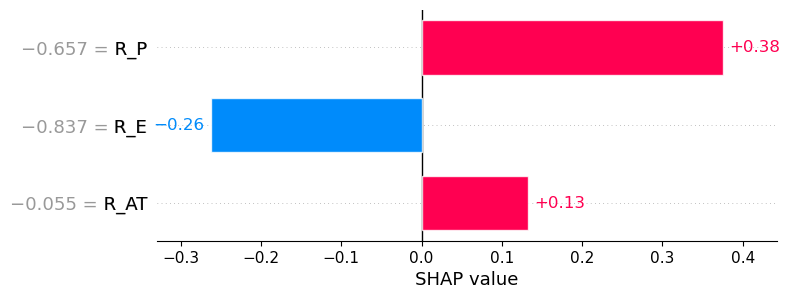

In [53]:
# Local bar plot
shap.plots.bar(shap_valuests[0])

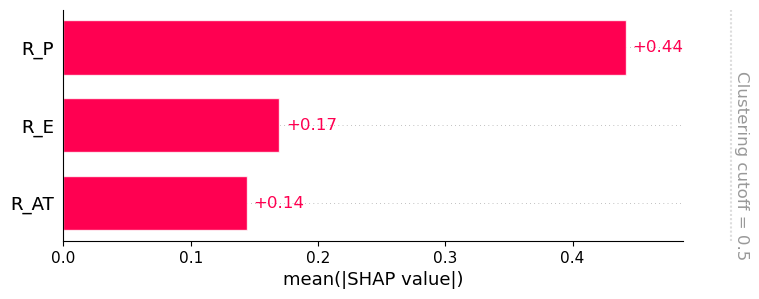

In [54]:
# Feature clustering
clustering = shap.utils.hclust(X_R_test, y_G_test)
shap.plots.bar(shap_valuests, clustering = clustering)

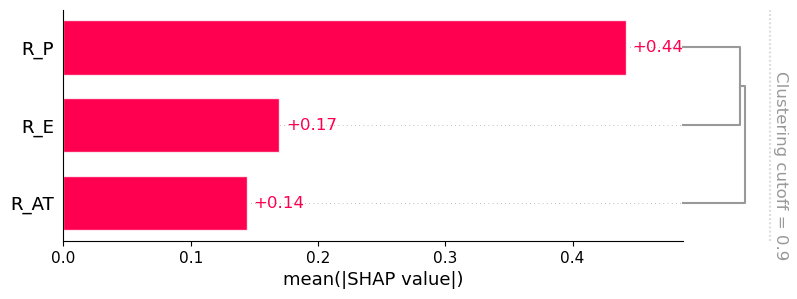

In [55]:
# Feature clustering
clustering = shap.utils.hclust(X_R_test, y_G_test)
shap.plots.bar(shap_valuests, clustering = clustering, clustering_cutoff = 0.9)

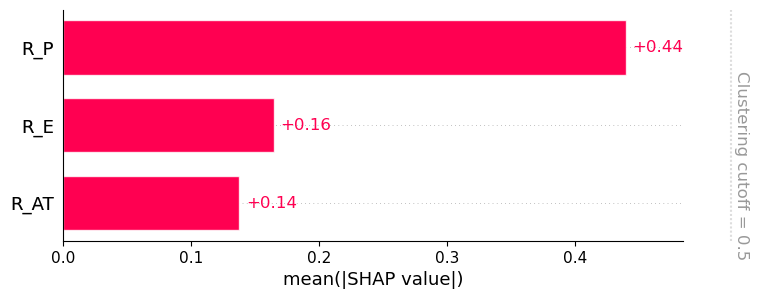

In [56]:
# shap.maskers.TabularPartitions
def f(x):
    return gbr3.predict(x)
# Defining a partition nasker that uses the ckustering
masker = shap.maskers.Partition(X_R_test, clustering = clustering)

# Model explanation

explainerts = shap.Explainer(f, masker)

# shap_values

shap_values_partition = explainerts(X_R_test)

# Generating the plot

shap.plots.bar(shap_values_partition)


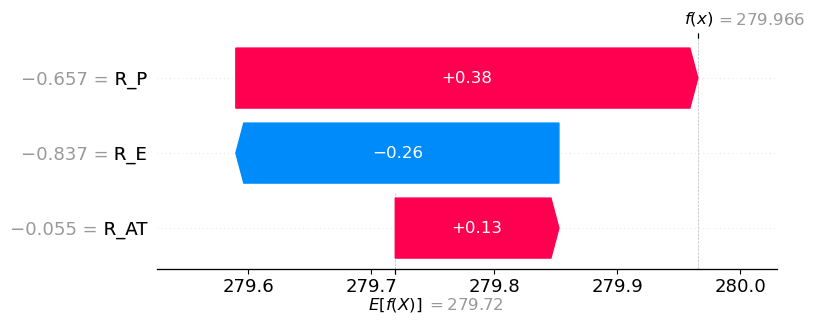

In [57]:
 # Waterfall plot
shap.plots.waterfall(shap_valuests[0])

In [58]:
# Force plot
shap.plots.force(shap_valuests[0])

In [ ]:
   ################################ END ##########################